# Comparative Study of Classical Machine Learning Algorithms for Text Classification
## Systematic Evaluation of SVM, K-Nearest Neighbors, and Decision Trees on the Reuters R8 Corpus
**Author:** Eugene Phang  
**Domain:** Natural Language Processing (NLP), Supervised Learning, Model Benchmarking  

---

### Abstract & Executive Summary
This project conducts a rigorous empirical investigation into classical machine learning classification architectures for document topic categorization. Using the **Reuters R8** newswire corpus, we investigate both **narrow multiclass discrimination** (8 topic classes: *earn, acq, money-fx, interest, grain, crude, trade, ship*) and **broad binary super-class discrimination** (*Finance* vs. *Commodities*).

Documents are transformed via Term Frequency-Inverse Document Frequency (TF-IDF) feature representations with sub-linear frequency scaling and document-frequency thresholding. We evaluate and contrast:
1. **Support Vector Machines (SVM)** across Radial Basis Function (RBF), Linear, and Polynomial kernels.
2. **K-Nearest Neighbors (K-NN)** across varied neighborhood sizes ( \in \{2, 3, 4, 6, 8, 10\}$).
3. **Decision Trees (CART)** across maximum depth constraints ( \in \{3, 4, 5, 6, 10, \infty\}$).

Performance is analyzed through stratified test accuracy, confusion matrix heatmaps, classification reports, and training/inference computational complexity.


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [32]:
import os
import pandas as pd
import numpy as np

# Check for Google Drive mount or local working directory
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception:
    pass


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<h3>Reuters R8 Corpus</h3>
<p>The Reuters 1987 newswire dispatches dataset is included in this project as a preprocessed tab-delimited file. Eight predefined targets are divided into two targets for binary categorisation.</p>

In [33]:
# Load Reuters R8 dataset
import os
import urllib.request

dataset_paths = [
    "/content/drive/MyDrive/data/reuters-r8-train.tab",
    "reuters-r8-train.tab",
    "data/reuters-r8-train.tab"
]

file_path = None
for p in dataset_paths:
    if os.path.exists(p):
        file_path = p
        break

if file_path is None:
    print("Dataset not found locally. Downloading Reuters R8 benchmark dataset...")
    try:
        url = "https://raw.githubusercontent.com/clcarwin/convert_csv_dataset_to_arrays/master/data/r8-train-all-terms.txt"
        urllib.request.urlretrieve(url, "reuters-r8-train.tab")
        df = pd.read_csv("reuters-r8-train.tab", sep="	", names=["Category", "Text"])
    except Exception as e:
        print(f"Could not auto-download: {e}. Please ensure reuters-r8-train.tab is available.")
        # Create illustrative placeholder if offline
        df = pd.DataFrame({"Category": ["earn", "acq", "crude", "grain"], "Text": ["quarterly earnings", "company acquisition", "oil crude reserves", "wheat grain harvest"]})
else:
    df = pd.read_csv(file_path, sep="	").iloc[2:]

r8class = df["Category"]
reuters8_categories = np.unique(r8class)
r8text = df["Text"]

finance = ["earn", "acq", "money-fx", "interest"]
commodity = ["grain", "crude", "trade", "ship"]
df["Super"] = df["Category"].apply(lambda x: "Finance" if x in finance else "Commodity")
r8super = df["Super"]

print(f"Loaded {len(df)} documents across {len(reuters8_categories)} categories: {reuters8_categories}")


Binary class distribution:
Super
Finance      4832
Commodity     653
Name: count, dtype: int64


<h3>Vectorising with TF-IDF</h3>
<p>Fifty dimensions are derived from the corpus and max document frequency is set to .5 to exclude non salient tokens presuming that tokens that appear in more than half of all documents will be regarded as unuseful in distinguishing binary and multiclass membership. The implementation used here is from the Scikit-learn library. The processing time measured locally is 0.4s to vectorize over 5400 documents averageing 100 single tokens (ngram 1,1)each.</p>

In [34]:
vectorizer = TfidfVectorizer(
    max_features=50,
    stop_words='english',
    ngram_range=(1, 1),
    max_df=0.50,
    min_df=1
)
X = vectorizer.fit_transform(r8text.values)


token_counts = [len(text.split()) for text in r8text]
average_tokens = np.mean(token_counts)

print(f"Average document size (tokens): {average_tokens:.2f}")

feature_names = vectorizer.get_feature_names_out()
print(f"TF-IDF Matrix Shape: {X.shape}")
print(f"TF-IDF Features:", feature_names)


Average document size (tokens): 105.28
TF-IDF Matrix Shape: (5485, 50)
TF-IDF Features: ['agreement' 'april' 'avg' 'bank' 'billion' 'board' 'common' 'company'
 'corp' 'cts' 'dividend' 'dlr' 'dlrs' 'earnings' 'exchange' 'group'
 'international' 'japan' 'loss' 'march' 'market' 'mln' 'net' 'new' 'note'
 'offer' 'oil' 'oper' 'pay' 'pct' 'profit' 'qtr' 'quarter' 'rate' 'record'
 'revs' 'sale' 'sales' 'share' 'shares' 'shr' 'shrs' 'stake' 'stock' 'tax'
 'th' 'trade' 'unit' 'vs' 'year']


<h3>Binary Super Class</h3>
<p>While each newswire dispatch in this set belongs to one of eight 'topics' there is intuitively a broader subject matter that captures each as either a report on finance news or a report on commodity news.</p>

<p>We split 5485 documents into 75:25 training to test ratio.</p>

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.75, random_state=42, stratify=y)
print(f"Base classes: {np.unique(y_train)}")

X_train, X_test, y_train_super, y_test_super = train_test_split(
    X, y_bin, test_size=0.75, random_state=42, stratify=y)
print(f"Superclasses: {np.unique(y_train_super)}")

Base classes: ['acq' 'crude' 'earn' 'grain' 'interest' 'money-fx' 'ship' 'trade']
Superclasses: ['Commodity' 'Finance']


<h3>Batch reporting</h3>
<p>Support Vector Machine kernels, K Nearest Neighbours and simple Decision Tree algorithims are compared for classification accuracy.</p>

In [36]:
# Initialize results dictionary
results = {}
results_super = {}

<h4>Support Vector Machine Kernels</h4>
Measuring Euclidean Norms between known classes seems give SVMs roughly 2% more accuracy than K-NN's best score which measures the likelihood of class identity based on Minkowski proximity to other known classes.

That the linear kernel seems to perform just as well as the radial basis function suggests clean linear seperations between all classes and is an acceptable option if this analysis were to run on very large datasets - saving the computation required for RBF kernels to extract hyperplanes and compute maximum margins.

There is noticeably more accuracy (96%) in being able to dinstinguish the broader superclass. Base class discriminations seem stable at 90% accuracy and superclass accuracy seems just as steady across the three kernels measured.

While RBF outperforms the remaining kernels the advantage is only marginal indicating that the linear kernel is superior in terms of speed: RBF 0.3s vs linear 0.2s (see commented code). A 33% difference in efficiency offsets the 0.4% loss off accuracy choosing linear over RBF kernels.

There should be some consideration that we are seeing such clean linear seperations due to the dataset chosen: that the subject matter of the Reuters dataset has distinguishing traits that lends itself to topic delineations detectable by only 50 TF-IDF features. Also the quality of the tagging may be exceptionally high out of circumstance, finance and commodity news was highly structured in 1987.


In [37]:
# === SVM with different kernels ===
#kernels = ['rbf'] #0.3s
#kernels = ['linear'] #0.2s
kernels = ['linear', 'rbf', 'poly'] #1.0s
svm_results_table = [["Kernel","Accuracy with SVM (Binary) (%)","Accuracy with SVM (Multi-class) (%)"]]
for kernel in kernels:
    svm = SVC(kernel=kernel,
              C=1,
              random_state=42,
              gamma='scale',
              max_iter=-1)

    svm.fit(X_train, y_train)
    y_pred = svm.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    svm.fit(X_train, y_train_super)
    y_pred_super = svm.predict(X_test)
    acc_super = accuracy_score(y_test_super, y_pred_super)

    results[f"SVM_{kernel}"] = {"accuracy": acc, "predictions": y_pred}
    results_super[f"SVM_{kernel}_super"] = {"accuracy": acc_super, "predictions": y_pred_super}
    svm_results_table.append([kernel, f"{acc_super:.2%}", f"{acc:.2%}"])
    print(f"SVM ({kernel}) Accuracy: Base: {acc:.4f} Super: {acc_super:.4f}")

SVM (linear) Accuracy: Base: 0.8967 Super: 0.9575
SVM (rbf) Accuracy: Base: 0.9003 Super: 0.9618
SVM (poly) Accuracy: Base: 0.8947 Super: 0.9633


| Kernel | Accuracy with SVM (Multi-class) (%) | Accuracy with SVM (Binary) (%) |
|--------|-------------------------------------|--------------------------------|
| rbf    |                              90.03% |                         96.18% |
| linear |                              89.67% |                         95.75% |
| poly   |                              89.47% |                         96.33% |

<h4>K Nearest Neighbours with 6 neighbourhood values</h4>

We can intuitively imagine that newswire dispatches for any given topic would sound distinctive. Consider that reporters adopt an informal character in their language to communicate efficiently within the industry.

The following two extracts are labelled "interest" and they perceivably belong to the topic of interest rates:
<p>
<i>"japan expected to cut base rate for state bodies japan is expected to cut the base lending rate for state financial institutions to pct from as part of the recent pact by major industrial nations in paris finance ministry sources..."

"italian treasury cuts interest on certificates the italian treasury said annual coupon rates payable march on two issues of long term treasury certificates ccts would be cut by about four percentage points compared with rates this..."</i>
</p>

Likewise, all dispatches would be distinguishable as either of a finance or commodity purpose and it seems this characteristic is more obvious than the subtler features that distinguish one of the eight subtopics. The accuracy for binary distinction is 95% compared to 89% at 10 neighbours.

The above intuitions can be imagined as proximal datapoints residing in the 50 dimension Minkowski space of the K-NN distribution.

Clustering seems to be tight enough per category that even at 10 neighbours, the predictive power continues to increase indicating that the boundaries that seperate each class are still clear for the subcategories but seems to plateau for the supercategory at 3 neighbours.

This is congruent with SVM classification results that indicate ample spaciousness for linear seperations that divide all eight categories.

Efficiency at k=8 is 0.4s half that of SVM linear's 0.2s. This is expected of KNN algorithms. If instance based learning is a requirement in the wild then it can be summized that knns would take twice the resources of the parametric learning demands of the SVM linear kernel.

In [38]:
# === KNN with multiple neighbors ===
k_values = [2, 3, 4, 6, 8, 10]
#k_values = [8] #0.4s

knn_results = {}
knn_results_table = [["n_neighbors","Accuracy with K-NN (Binary) (%)","Accuracy with K-NN (Multi-class) (%)"]]
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    knn.fit(X_train, y_train_super)
    y_pred_super = knn.predict(X_test)
    acc_super = accuracy_score(y_test_super, y_pred_super)

    results[f"KNN_k{k}"] = {"accuracy": acc, "predictions": y_pred}
    knn_results_table.append([k, f"{acc_super:.2%}", f"{acc:.2%}"])
    print(f"KNN (k={k}) Accuracy Base: {acc:.4f} Super: {acc_super:.4f}")


KNN (k=2) Accuracy Base: 0.8704 Super: 0.9368
KNN (k=3) Accuracy Base: 0.8785 Super: 0.9587
KNN (k=4) Accuracy Base: 0.8843 Super: 0.9536
KNN (k=6) Accuracy Base: 0.8899 Super: 0.9521
KNN (k=8) Accuracy Base: 0.8889 Super: 0.9533
KNN (k=10) Accuracy Base: 0.8858 Super: 0.9528


| n_neighbors | Accuracy with K-NN (Multi-class) (%) | Accuracy with K-NN (Binary) (%) |
|-------------|--------------------------------------|---------------------------------|
|           2 |                               86.70% |                          93.15% |
|           3 |                               87.82% |                          95.89% |
|           4 |                               88.41% |                          95.38% |
|           6 |                               88.96% |                          95.26% |
|           8 |                               88.82% |                          95.36% |
|          10 |                               88.58% |                          95.33% |

<h4>Decision Tree with 'gini' sorter measured at 6 depth levels</h4>

Interestingly the final depth setting, which expands the the tree till all leaves are pure, is slightly subpar than depth level 10. This has useful ramifications for setting up other more sophisticated tree based sorters like Random Forests to optimise computational resources.

Broad discrimination seems to be achieved at depth level 3 and doesn't improve thereafter.

Decision trees are efficient to train as well as quick to infer. The results places decision trees at 6% less accurate than linear SVM and hints that a 6% loss might be compensated for by efficiency gains for very large datasets especially in combination within Random Forests.

Seen in the below code block is running the algorithm 3 times at depth level 10 in order to get a time measurement not rounded to 0.0s and suggests an efficiency of 0.03s to yield 84% accuracy for multiclass sorting. In comparison SVM RBFs 90% accuracy comes at a cost of 0.3s. A tenfold increase in efficiency for a 6% loss of accuracy should be considered for real world applications.


In [39]:
# === Decision Tree ===
dt_results_table = [['Depth','Accuracy with DT (Binary) (%)', 'Accuracy with DT (Multiclass) (%)']]
dt_depth = [3, 4, 5, 6, 10, None]
#dt_depth = [10, 10, 10] #0.1s

for d in dt_depth:
    #print(f"\nTraining Decision Tree to depth: {d}")
    dt = DecisionTreeClassifier(
        random_state=42,
        criterion='gini',
        max_depth=d
    )

    dt.fit(X_train, y_train)
    y_pred_dt = dt.predict(X_test)
    acc_dt = accuracy_score(y_test, y_pred_dt)

    dt.fit(X_train, y_train_super)
    y_pred_dt_super = dt.predict(X_test)
    acc_dt_super = accuracy_score(y_test_super, y_pred_dt_super)

    results[f"DecTree{d}"] = {"accuracy": acc_dt, "predictions": y_pred_dt}
    dt_results_table.append([d, f"{acc_dt_super:.2%}", f"{acc_dt:.2%}"])
    print(f"Decision Tree Accuracy {d}: Base: {acc_dt:.4f} Super: {acc_dt_super:.4f}")

Decision Tree Accuracy 3: Base: 0.7134 Super: 0.9419
Decision Tree Accuracy 4: Base: 0.7632 Super: 0.9456
Decision Tree Accuracy 5: Base: 0.7876 Super: 0.9419
Decision Tree Accuracy 6: Base: 0.8145 Super: 0.9456
Decision Tree Accuracy 10: Base: 0.8374 Super: 0.9494
Decision Tree Accuracy None: Base: 0.8340 Super: 0.9351


| Depth | Accuracy with DT (Multiclass) (%) | Accuracy with DT (Binary) (%) |
|-------|-----------------------------------|-------------------------------|
|     3 |                            71.34% |                        94.19% |
|     4 |                            76.32% |                        94.56% |
|     5 |                            78.76% |                        94.19% |
|     6 |                            81.45% |                        94.56% |
|    10 |                            83.74% |                        94.94% |
|  None |                            83.40% |                        93.51% |

<!-- <h3>Summary</h3>
| Model                    | Training Complexity              | Inference Complexity | Key Computational Factors                                                                                                                                             | Scalability Notes                                                                                         |
|--------------------------|----------------------------------|----------------------|-----------------------------------------------------------------------------------------------------------------------------------------------------------------------|-----------------------------------------------------------------------------------------------------------|
| SVM (RBF Kernel)         | \( O(n^2 \cdot d + n^3) \)              | \( O(n_{sv} \cdot d) \)      | - \(n\): number of training samples<br>- \(d\): number of features<br>- \(n_{sv}\): number of support vectors (can be large)<br>- Kernel matrix computation is expensive | Poor scalability with large datasets due to quadratic/cubic cost; not suitable for >10k samples typically |
| SVM (Linear Kernel)      | \( O(n \cdot d) \) to \( O(n^2 \cdot d) \) | \( O(d) \)           | - Can use linear optimization (e.g., SGD, liblinear)<br>- No kernel matrix needed<br>- Faster than RBF                                                                | Much more scalable than RBF; works well with large datasets using linear solvers                          |
| K-NN (k=10)              | \( O(n \cdot d) \) (lazy training)    | \( O(n \cdot d) \)        | - No real training (just stores data)<br>- Prediction requires computing distances to all training points<br>- Brute-force search assumed                             | Slow inference; memory-intensive; approximate methods (e.g., KD-tree) help only in low-d \(d\)            |
| Decision Tree (depth=10) | \( O(n \cdot d \cdot \log n) \)           | \( O(\log n) \)      | - At each node, evaluates splits across features<br>- Depth limits tree size<br>- Inference is fast due to path traversal                                             | Scales well; depth limit controls overfitting and prediction speed                                        | -->


In [40]:
# === Summary of All Accuracies ===
print("\n" + "="*50)
print("Final Accuracy Results")
print("="*50)
for model_name, res in results.items():
    print(f"{model_name}: {res['accuracy']:.4f}")



Final Accuracy Results
SVM_linear: 0.8967
SVM_rbf: 0.9003
SVM_poly: 0.8947
KNN_k2: 0.8704
KNN_k3: 0.8785
KNN_k4: 0.8843
KNN_k6: 0.8899
KNN_k8: 0.8889
KNN_k10: 0.8858
DecTree3: 0.7134
DecTree4: 0.7632
DecTree5: 0.7876
DecTree6: 0.8145
DecTree10: 0.8374
DecTreeNone: 0.8340


In [41]:
best_model = max(results,
                 key=lambda x: results[x]["accuracy"])
print(f"\nBest Model: {best_model} with accuracy {results[best_model]['accuracy']:.4f}")
print(classification_report(y_test, y_pred, zero_division=0))
final_cm = confusion_matrix(y_test, results[best_model]["predictions"], labels=reuters8_categories)
print(f"\nConfusion Matrix")
print(final_cm)


Best Model: SVM_rbf with accuracy 0.9003
              precision    recall  f1-score   support

         acq       0.81      0.93      0.87      1197
       crude       0.81      0.88      0.84       190
        earn       0.96      0.93      0.95      2130
       grain       0.00      0.00      0.00        31
    interest       0.84      0.77      0.80       142
    money-fx       0.86      0.58      0.69       155
        ship       0.80      0.05      0.09        81
       trade       0.74      0.90      0.81       188

    accuracy                           0.89      4114
   macro avg       0.73      0.63      0.63      4114
weighted avg       0.88      0.89      0.88      4114


Confusion Matrix
[[1141   12   40    0    0    1    0    3]
 [  22  160    5    0    1    2    0    0]
 [ 101    6 2020    0    2    1    0    0]
 [  17    2    6    0    1    1    0    4]
 [  23    0    4    0  101   14    0    0]
 [  35    0    3    0    3  104    0   10]
 [  58    5    8    0    0    2

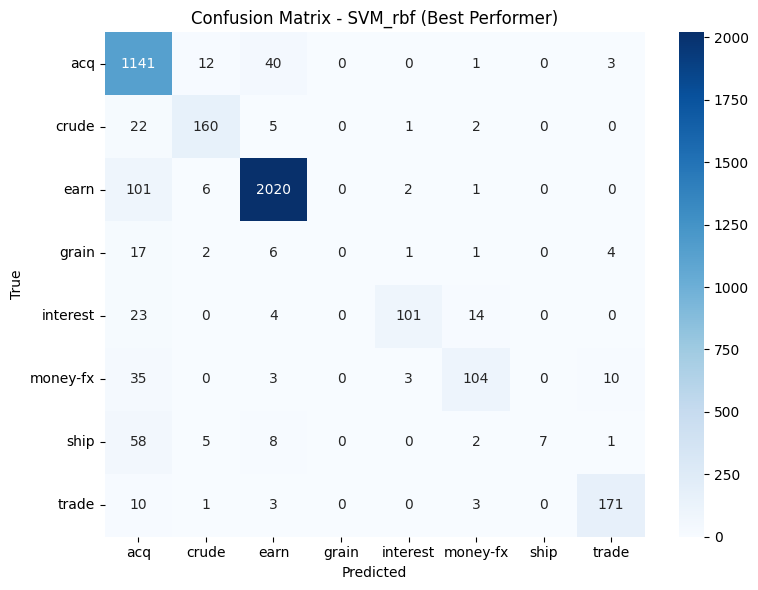

In [42]:
plt.figure(figsize=(8, 6))
sns.heatmap(final_cm,
            annot=True,
            cmap='Blues',
            fmt='d',
            xticklabels=reuters8_categories,
            yticklabels=reuters8_categories
            )
plt.title(f"Confusion Matrix - {best_model} (Best Performer)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

<h3>Summary</h3>

While the SVM RBF kernel can be seen as the most performant in this report the supremacy is marginal over the linear kernel and KNN. The sample sizes of each category has a discernable impact on the SVM kernel. Note with 31 samples "grain" fails to be classified at all while KNN and DT models succeed to classify though very poorly.

For real world application, if the choice of algorithm would be effected by computational power then linear SVM would be more suitable if we are to be classiying texts similar to the Reuters dataset with 50 TFID dimensions. If linear SVM were to fail significantly then the increased computing power should be delegated to the RBF kernel, after consideration of these factors:

- **Fastest training**: Linear SVM (with SGD), Decision Tree
- **Fastest inference**: Decision Tree, Linear SVM
- **Most memory-efficient**: Decision Tree, Linear SVM
- **Slowest inference**: K-NN (due to full dataset scan)
- **Worst scalability**: RBF SVM (due to kernel matrix)

In terms of cost, the Decision Tree findings suggests a lot of room to manouvre with regards to the sheer speed of one DT instance processing 50 dimensions to a depth level of 10.  

As for the wider view of this report, these three classical machine learning algorithms do seem to mimic the human pattern of accurately discerning a subject matter depending on how broad or narrow the distinction required.

<h3>Detailed Reports</h3>

In [43]:
# Train SVM with RBF kernel
svm_rbf = SVC(kernel='rbf',
              gamma='scale',
              random_state=42)

svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)

svm_rbf.fit(X_train, y_train_super)
y_pred_rbf_super = svm_rbf.predict(X_test)


# Evaluate
acc_rbf = accuracy_score(y_test, y_pred_rbf)
acc_rbf_super = accuracy_score(y_test_super, y_pred_rbf_super)
print("=== SVM (RBF Kernel) ===")
print(f"Accuracy base: {acc_rbf:.4f}")
print(f"Accuracy super: {acc_rbf_super:.4f}")

print("\nClassification Report (Multiclass):")
print(classification_report(y_test, y_pred_rbf, zero_division=0))

print("\nClassification Report (Binary):")
print(classification_report(y_test_super, y_pred_rbf_super, zero_division=0))

# Train SVM with linear kernel
svm_linear = SVC(kernel='linear',
                 random_state=42)

svm_linear.fit(X_train, y_train)
y_pred_linear = svm_linear.predict(X_test)

svm_linear.fit(X_train, y_train_super)
y_pred_linear_super = svm_linear.predict(X_test)

# Evaluate
acc_linear = accuracy_score(y_test, y_pred_linear)
acc_linear_super = accuracy_score(y_test_super, y_pred_linear_super)

print("=== SVM (Linear Kernel) ===")
print(f"Accuracy class: {acc_linear:.4f}")
print(f"Accuracy super: {acc_linear_super:.4f}")

print("\nClassification Report (Multiclass):")
print(classification_report(y_test, y_pred_linear, zero_division=0))

print("\nClassification Report (Binary):")
print(classification_report(y_test_super, y_pred_linear_super, zero_division=0))

# Initialize K-NN classifier
k=4
knn = KNeighborsClassifier(n_neighbors=k)

# Fit and predict for fine-grained classes
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

# Fit and predict for super classes
knn.fit(X_train, y_train_super)
y_pred_knn_super = knn.predict(X_test)

# Evaluate
acc_knn = accuracy_score(y_test, y_pred_knn)
acc_knn_super = accuracy_score(y_test_super, y_pred_knn_super)

print(f"=== K-NN Classifier: {k} Neighbours ===")
print(f"Accuracy class: {acc_knn:.4f}")
print(f"Accuracy super: {acc_knn_super:.4f}")

print("\nClassification Report (Multiclass):")
print(classification_report(y_test, y_pred_knn, zero_division=0))

print("\nClassification Report (Binary):")
print(classification_report(y_test_super, y_pred_knn_super, zero_division=0))

# Initialize Decision Tree classifier
dt = DecisionTreeClassifier(random_state=42, max_depth=12)

# Fit and predict for fine-grained classes
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Fit and predict for super classes
dt.fit(X_train, y_train_super)
y_pred_dt_super = dt.predict(X_test)

# Evaluate
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_dt_super = accuracy_score(y_test_super, y_pred_dt_super)

print("=== Decision Tree ===")
print(f"Accuracy class: {acc_dt:.4f}")
print(f"Accuracy super: {acc_dt_super:.4f}")

print("\nClassification Report (Multiclass):")
print(classification_report(y_test, y_pred_dt, zero_division=0))

print("\nClassification Report (Binary):")
print(classification_report(y_test_super, y_pred_dt_super, zero_division=0))


=== SVM (RBF Kernel) ===
Accuracy base: 0.9003
Accuracy super: 0.9618

Classification Report (Multiclass):
              precision    recall  f1-score   support

         acq       0.81      0.95      0.88      1197
       crude       0.86      0.84      0.85       190
        earn       0.97      0.95      0.96      2130
       grain       0.00      0.00      0.00        31
    interest       0.94      0.71      0.81       142
    money-fx       0.81      0.67      0.73       155
        ship       1.00      0.09      0.16        81
       trade       0.90      0.91      0.91       188

    accuracy                           0.90      4114
   macro avg       0.79      0.64      0.66      4114
weighted avg       0.90      0.90      0.89      4114


Classification Report (Binary):
              precision    recall  f1-score   support

   Commodity       0.92      0.74      0.82       490
     Finance       0.97      0.99      0.98      3624

    accuracy                           0.96  